In [1]:
# Install (only needed once in Colab)
!pip install xgboost

# Imports
import requests, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

np.random.seed(42)

In [2]:
MU = 398600
R_EARTH = 6371

BASE = "https://celestrak.org/NORAD/elements/gp.php"

CATALOG = {
    0: ("COSMOS-1408", f"{BASE}?GROUP=cosmos-1408-debris&FORMAT=TLE"),
    1: ("FENGYUN-1C", f"{BASE}?NAME=FENGYUN 1C DEB&FORMAT=TLE"),
    2: ("IRIDIUM-33", f"{BASE}?NAME=IRIDIUM 33 DEB&FORMAT=TLE"),
    3: ("COSMOS-2251", f"{BASE}?NAME=COSMOS 2251 DEB&FORMAT=TLE"),
    4: ("BREEZE-M", f"{BASE}?NAME=BREEZE-M DEB&FORMAT=TLE"),
}

names = {k: v[0] for k, v in CATALOG.items()}

In [3]:
def parse_tle(text):
    lines = [l.strip() for l in text.splitlines() if l.strip()]
    data = []
    for i in range(0, len(lines) - 2, 3):
        if lines[i+1].startswith("1 ") and lines[i+2].startswith("2 "):
            data.append((lines[i+1], lines[i+2]))
    return data


def extract_features(l2):
    try:
        i = float(l2[8:16])
        raan = float(l2[17:25])
        e = float("0." + l2[26:33].strip())
        argp = float(l2[34:42])
        n = float(l2[52:63])

        n_rad = n * 2 * np.pi / 86400
        a = (MU / n_rad**2) ** (1/3)

        return [a, e, i, raan, argp, n_rad]
    except:
        return None

In [4]:
rows = []

for sid, (name, url) in CATALOG.items():
    print(f"Fetching {name}...")
    try:
        r = requests.get(url, timeout=30)

        if not r.text.strip() or r.text.startswith("<"):
            print("Skipped (invalid response)")
            continue

        for l1, l2 in parse_tle(r.text):
            f = extract_features(l2)
            if f:
                rows.append(f + [sid])

    except Exception as e:
        print("Failed:", e)

if not rows:
    raise RuntimeError("No data fetched")

df = pd.DataFrame(rows, columns=[
    "a", "e", "i", "raan", "argp", "n", "target"
])

print("Dataset shape:", df.shape)
df.head()

Fetching COSMOS-1408...
Fetching FENGYUN-1C...
Fetching IRIDIUM-33...
Fetching COSMOS-2251...
Fetching BREEZE-M...
Dataset shape: (2747, 7)


,a,e,i,raan,argp,n,target
0,6802.865973,0.001690,82.5602,278.4828,79.0086,0.001125,0
1,6720.092473,0.001048,82.6060,285.5865,304.8445,0.001146,0
2,6787.189285,0.009015,82.1856,72.2838,85.2941,0.001129,0
3,6749.130156,0.002217,82.5640,291.1277,7.1311,0.001139,0
4,7653.161582,0.056483,99.2098,158.4072,246.8270,0.000943,1


In [5]:
print("Class Distribution:")
print(df["target"].value_counts())

if df["target"].nunique() < 2:
    raise RuntimeError("Need at least 2 classes")

Class Distribution:
target
1    1868
3     584
4     184
2     107
0       4
Name: count, dtype: int64


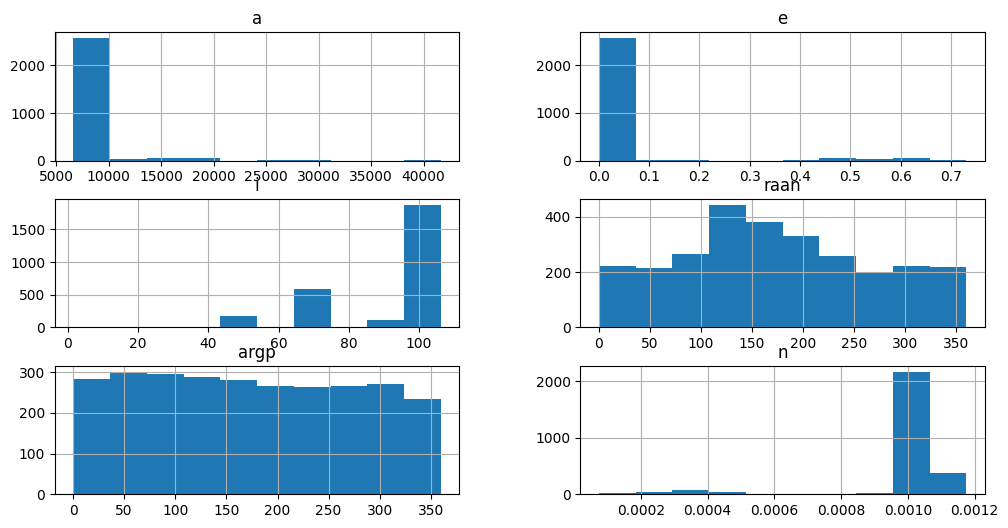

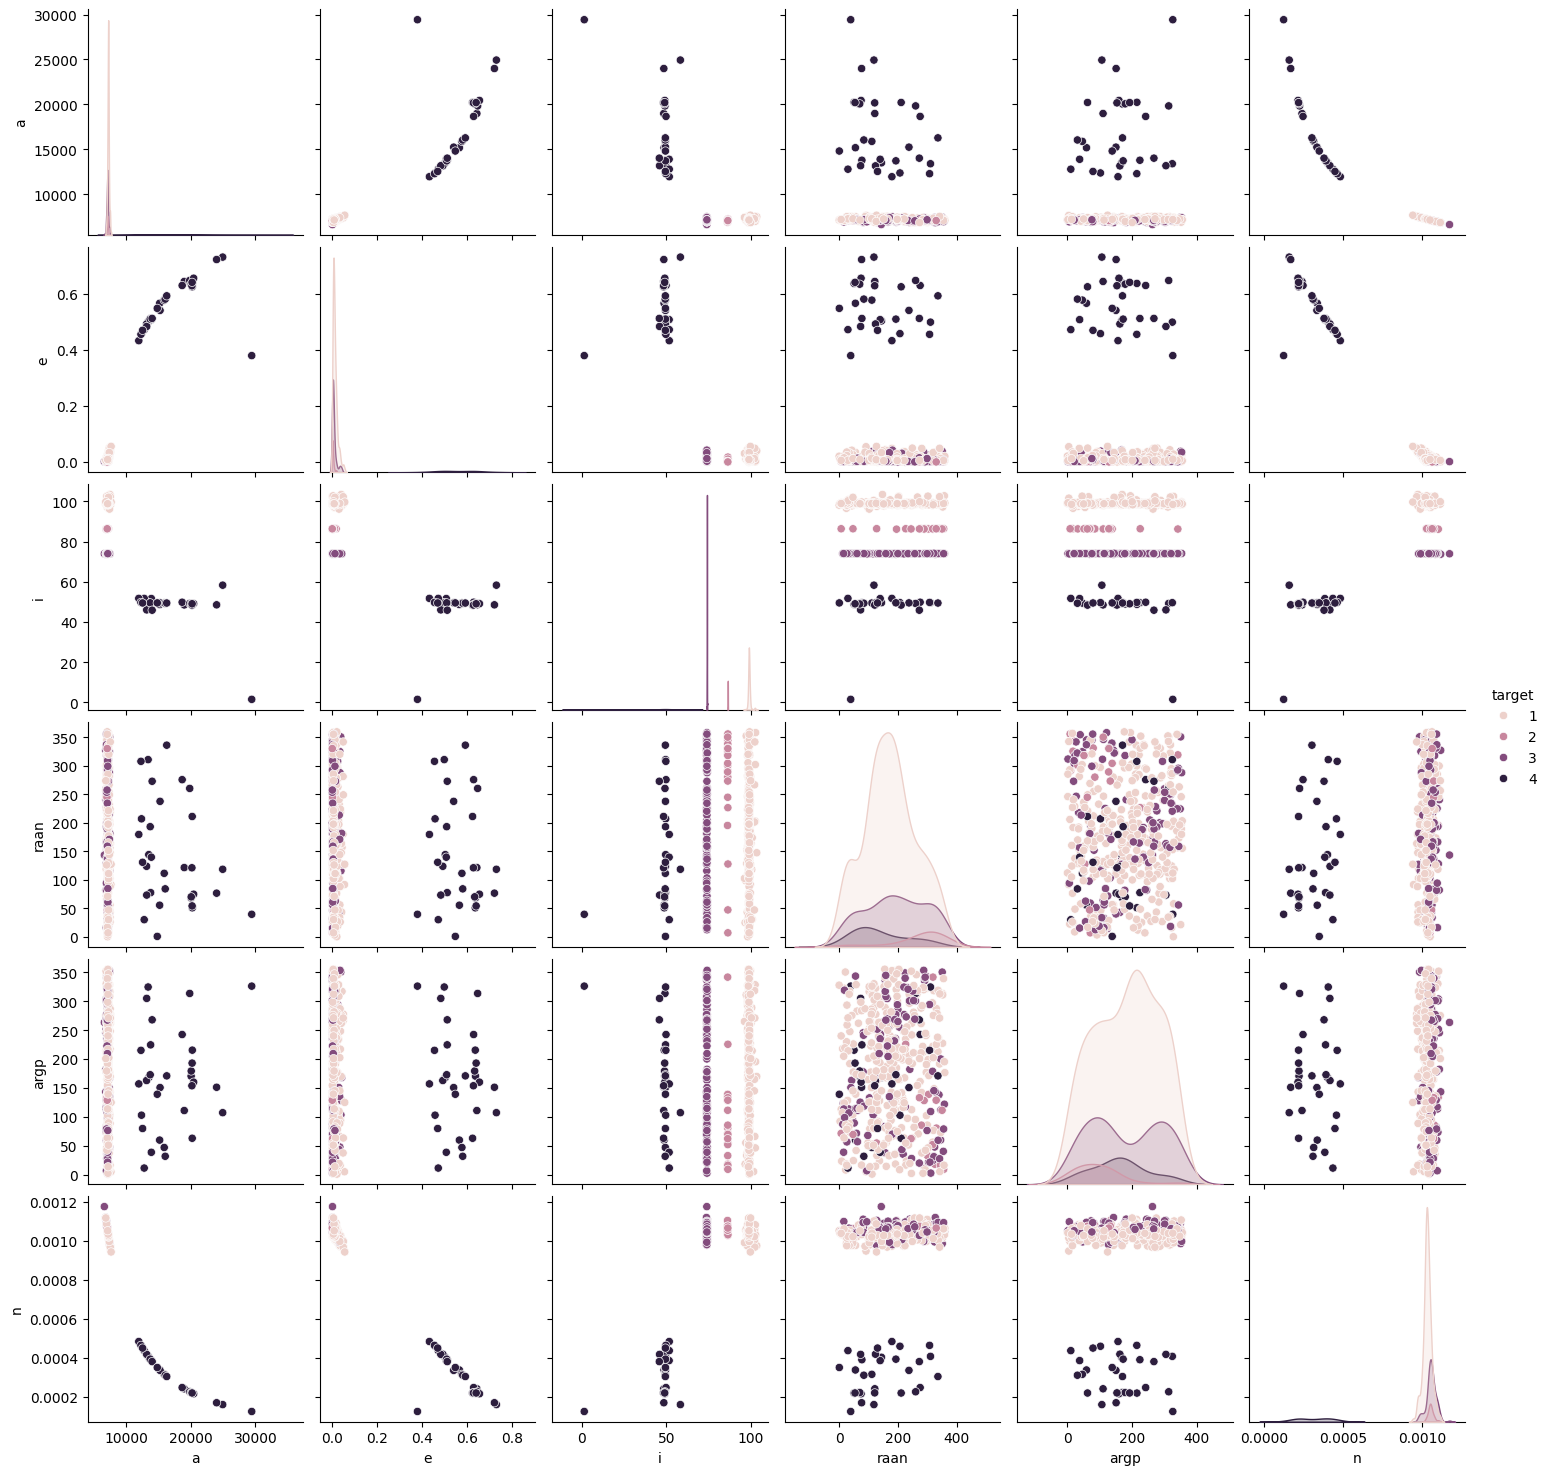

In [6]:
df.describe()
df.drop("target", axis=1).hist(figsize=(12,6))
plt.show()
sns.pairplot(df.sample(min(500, len(df))), hue="target")
plt.show()

In [7]:
X = df.drop("target", axis=1)
y = df["target"]

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (2197, 6) Test: (550, 6)


In [8]:
models = {
    "RF": RandomForestClassifier(class_weight="balanced"),
    "SVM": SVC(probability=True, class_weight="balanced"),
    "KNN": KNeighborsClassifier(),
    "XGB": XGBClassifier(eval_metric="mlogloss")
}

for name, m in models.items():
    m.fit(X_train, y_train)
    acc = accuracy_score(y_test, m.predict(X_test))
    print(name, ":", acc)

RF : 0.9981818181818182
SVM : 0.9981818181818182
KNN : 0.9945454545454545
XGB : 1.0


HYPERPARAMETER TUNING

In [9]:
rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight="balanced"),
    {"n_estimators":[100,200], "max_depth":[None,10]},
    n_iter=5, cv=3
)

rf_search.fit(X_train, y_train)
rf = rf_search.best_estimator_

print("Best RF:", rf_search.best_params_)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=5. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best RF: {'n_estimators': 100, 'max_depth': None}


In [10]:
xgb_search = RandomizedSearchCV(
    XGBClassifier(eval_metric="mlogloss"),
    {"n_estimators":[100,200], "max_depth":[3,6]},
    n_iter=5, cv=3
)

xgb_search.fit(X_train, y_train)
xgb = xgb_search.best_estimator_

print("Best XGB:", xgb_search.best_params_)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=5. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best XGB: {'n_estimators': 100, 'max_depth': 3}


ENSEMBLE MODEL


In [11]:
voting = VotingClassifier(
    estimators=[
        ("rf", rf),
        ("svm", models["SVM"]),
        ("knn", models["KNN"]),
        ("xgb", xgb)
    ],
    voting="soft"
)

voting.fit(X_train, y_train)

y_pred = voting.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9981818181818182
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       1.00      1.00      1.00       374
           2       0.95      1.00      0.98        21
           3       1.00      1.00      1.00       117
           4       1.00      1.00      1.00        37

    accuracy                           1.00       550
   macro avg       0.79      0.80      0.80       550
weighted avg       1.00      1.00      1.00       550



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


CONFUSION MATRIX


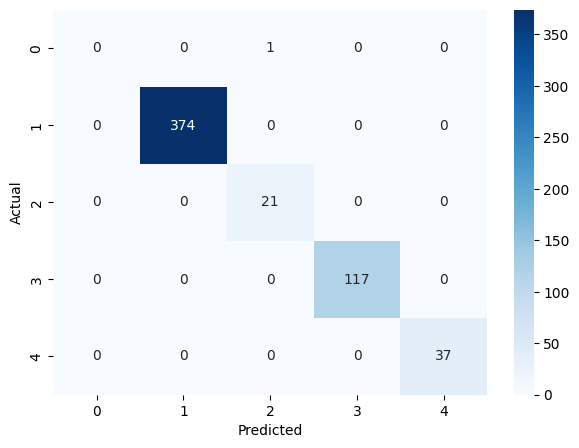

In [12]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

REAL TIME SIMULATION

In [13]:
indices = np.random.choice(len(X_test), size=5, replace=False)

for i, idx in enumerate(indices):
    frag = X_test[idx].reshape(1, -1)
    true = y_test.iloc[idx]

    probs = voting.predict_proba(frag)[0]
    pred = voting.classes_[np.argmax(probs)]

    print(f"\nDebris {i+1}")
    print("True:", names[true])
    print("Pred:", names[pred])
    print("Confidence:", max(probs))


Debris 1
True: COSMOS-2251
Pred: COSMOS-2251
Confidence: 0.8745243014687851

Debris 2
True: FENGYUN-1C
Pred: FENGYUN-1C
Confidence: 0.9998855537080346

Debris 3
True: FENGYUN-1C
Pred: FENGYUN-1C
Confidence: 0.999369875537574

Debris 4
True: FENGYUN-1C
Pred: FENGYUN-1C
Confidence: 0.9998193378653608

Debris 5
True: FENGYUN-1C
Pred: FENGYUN-1C
Confidence: 0.9998516202050125


UNKNOWN DEBRIS IDENTIFICATION

In [16]:
unknown = pd.DataFrame([{
    "a": R_EARTH + 510,
    "e": 0.5,
    "i": 500,
    "raan": 110,
    "argp": 50,
    "n": np.sqrt(MU / (R_EARTH + 510)**3)
}])

unknown_scaled = scaler.transform(unknown)

pred = voting.predict(unknown_scaled)[0]
probs = voting.predict_proba(unknown_scaled)[0]

print("Predicted:", names[pred])
print("Confidence:", max(probs))

Predicted: FENGYUN-1C
Confidence: 0.7161614899423225


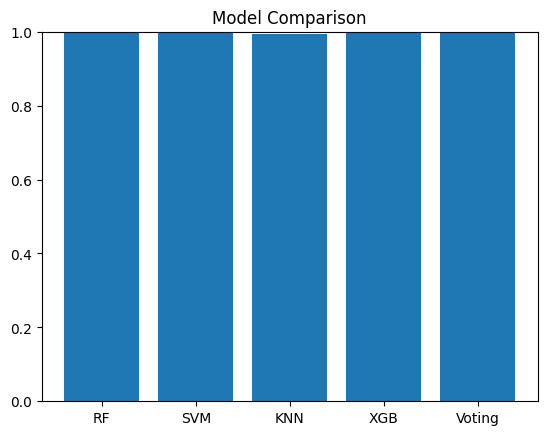

In [15]:
models_eval = {
    "RF": rf,
    "SVM": models["SVM"],
    "KNN": models["KNN"],
    "XGB": xgb,
    "Voting": voting
}

accs = [accuracy_score(y_test, m.predict(X_test)) for m in models_eval.values()]

plt.bar(models_eval.keys(), accs)
plt.ylim(0,1)
plt.title("Model Comparison")
plt.show()